#📌 Extracción

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/izual61/Challenge_TelecomX/c9dd1372d17e8211f6353ebce7b6a7e6ff7249f0/TelecomX_Data.json"

df = pd.read_json(url)



#🔧 Transformación

In [17]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])


df_final = pd.concat(
    [
        df[['customerID', 'Churn']],
        customer,
        phone,
        internet,
        account
    ],
    axis=1
)


df_final["Churn"] = df_final["Churn"].replace("", "No")


print(df_final["Churn"].value_counts(dropna=False))


print("Dimensiones del dataset:", df_final.shape)
display(df_final.head())

df_final.info()

Churn
No     5398
Yes    1869
Name: count, dtype: int64
Dimensiones del dataset: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#📊 Carga y análisis

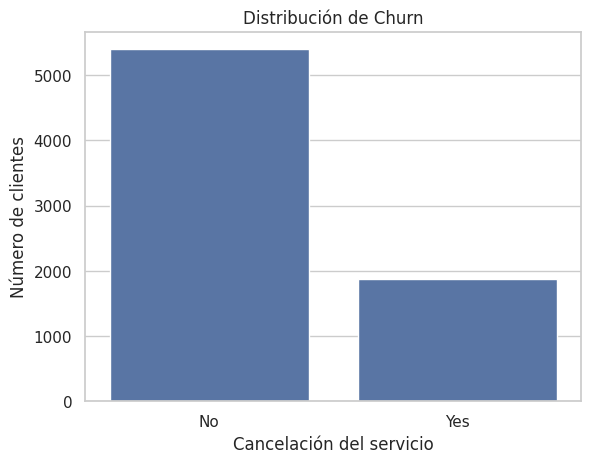

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

sns.countplot(x='Churn', data=df_final)

plt.title("Distribución de Churn")
plt.xlabel("Cancelación del servicio")
plt.ylabel("Número de clientes")

plt.show()

TIPO DE CONTRATO

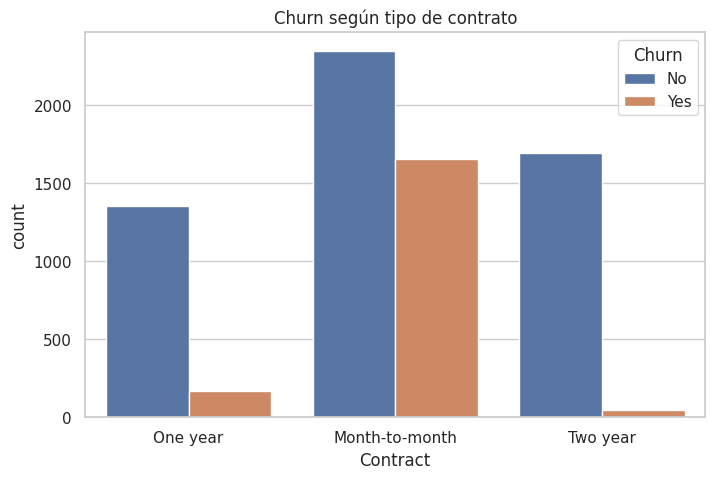

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df_final)

plt.title("Churn según tipo de contrato")

plt.show()

TIEMPO COMO CLIENTE

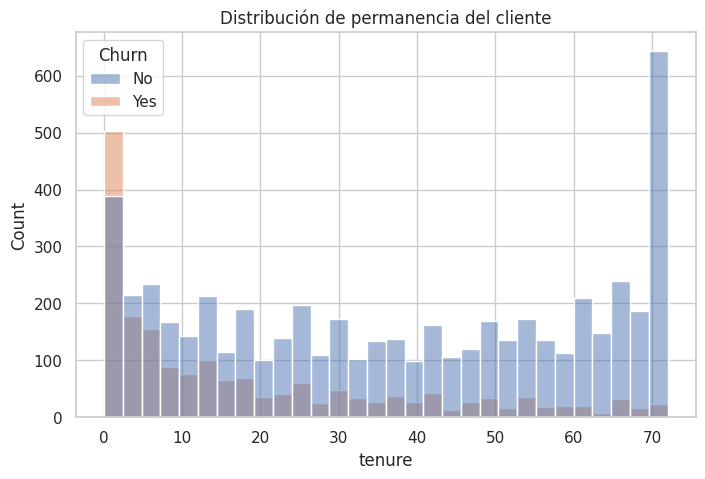

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(data=df_final, x="tenure", hue="Churn", bins=30)

plt.title("Distribución de permanencia del cliente")

plt.show()

CANTIDAD DE SERVICIOS CONTRATADOS

/tmp/ipykernel_165/2715711793.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_servicios = df_servicios.applymap(


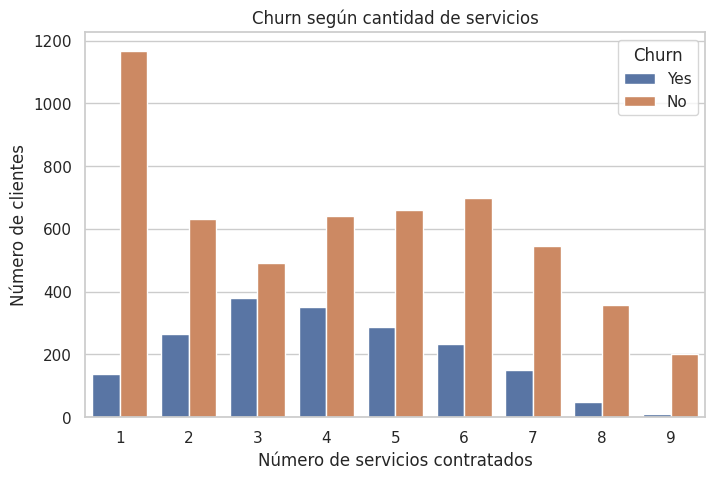

In [21]:
servicios = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_servicios = df_final[servicios].copy()

df_servicios = df_servicios.applymap(
    lambda x: 1 if str(x).lower() in ["yes", "dsl", "fiber optic"] else 0
)

df_final["TotalServicios"] = df_servicios.sum(axis=1)


plt.figure(figsize=(8,5))

sns.countplot(x="TotalServicios", hue="Churn", data=df_final)

plt.title("Churn según cantidad de servicios")
plt.xlabel("Número de servicios contratados")
plt.ylabel("Número de clientes")

plt.show()

TIPO DE SERVICIO

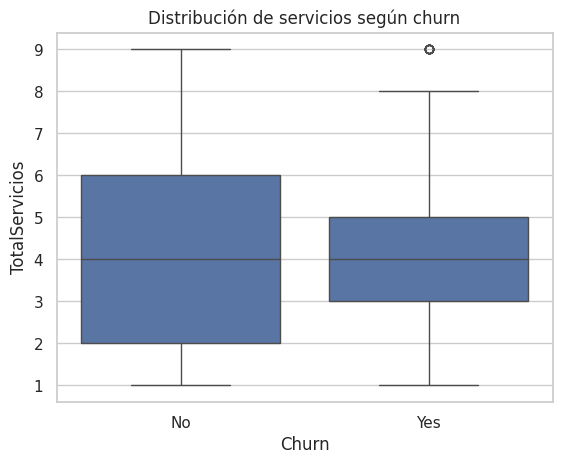

In [27]:
sns.boxplot(x="Churn", y="TotalServicios", data=df_final)

plt.title("Distribución de servicios según churn")

plt.show()

TIPO DE PAGO

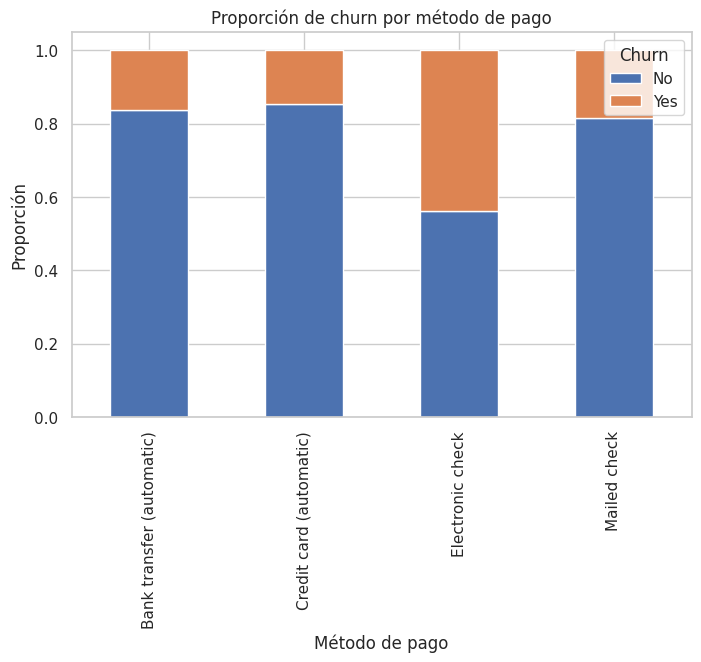

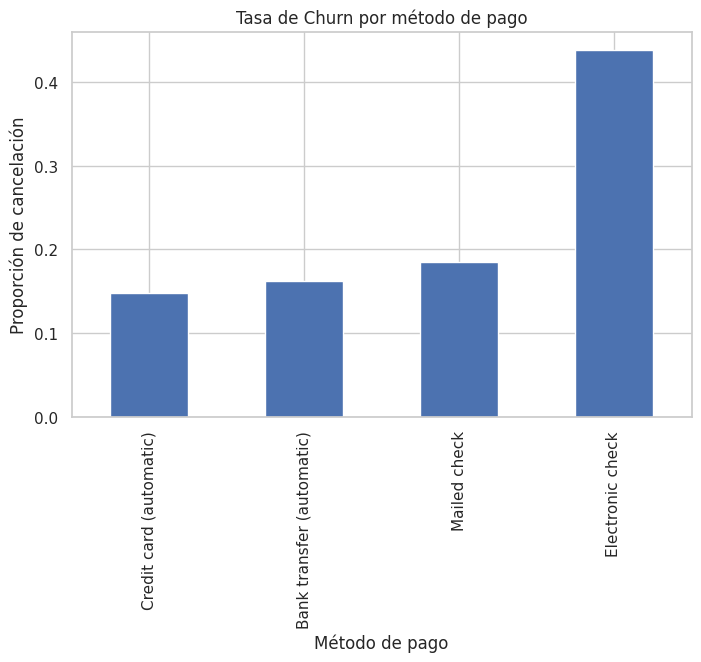

In [31]:
tabla = pd.crosstab(df_final["PaymentMethod"], df_final["Churn"], normalize="index")

tabla.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Proporción de churn por método de pago")
plt.ylabel("Proporción")
plt.xlabel("Método de pago")

plt.show()

churn_payment = (
    df_final.groupby("PaymentMethod")["Churn"]
    .value_counts(normalize=True)
    .unstack()
)

churn_payment["Yes"].sort_values().plot(kind="bar", figsize=(8,5))

plt.title("Tasa de Churn por método de pago")
plt.ylabel("Proporción de cancelación")
plt.xlabel("Método de pago")

plt.show()

MAYORES DE 65 AÑOS

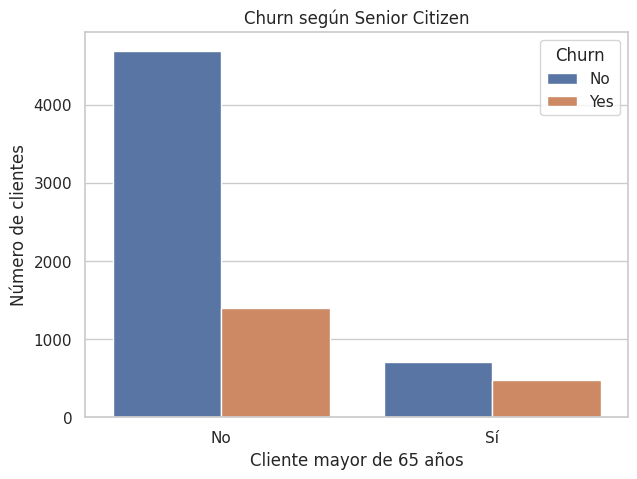

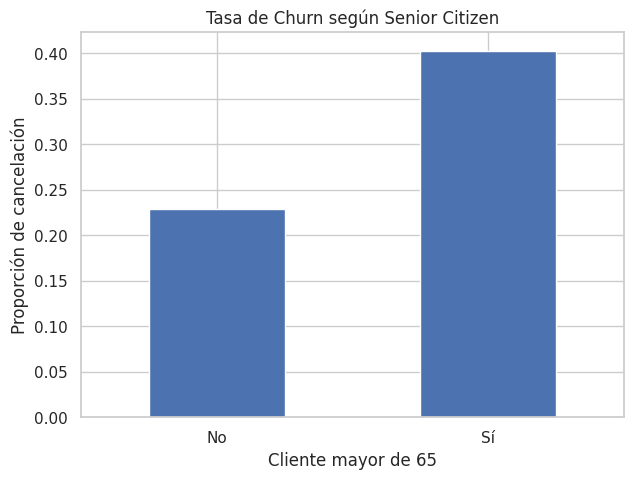

In [29]:
df_final["SeniorCitizen"].value_counts()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(x="SeniorCitizen", hue="Churn", data=df_final)

plt.title("Churn según Senior Citizen")
plt.xlabel("Cliente mayor de 65 años")
plt.ylabel("Número de clientes")

plt.xticks([0,1], ["No", "Sí"])

plt.show()

churn_senior = (
    df_final.groupby("SeniorCitizen")["Churn"]
    .value_counts(normalize=True)
    .unstack()
)

churn_senior["Yes"].plot(kind="bar", figsize=(7,5))

plt.title("Tasa de Churn según Senior Citizen")
plt.xlabel("Cliente mayor de 65")
plt.ylabel("Proporción de cancelación")

plt.xticks([0,1], ["No", "Sí"], rotation=0)

plt.show()




#📄Informe final


Conclusiones e Insights

Del análisis se observa que los clientes con menos servicios contratados tienden a cancelar más el servicio. En cambio, los clientes que tienen más servicios activos presentan menor churn, lo que sugiere que mientras más integrado está el cliente en los servicios de la empresa, menos probable es que se vaya.

También se encontró que el método de pago influye en la cancelación, ya que los clientes con pagos manuales presentan más churn que aquellos que usan pagos automáticos. Además, los clientes mayores de 65 años (Senior Citizens) muestran una ligera tendencia mayor a cancelar el servicio en comparación con los clientes más jóvenes.

En general, el churn parece estar relacionado con la cantidad de servicios contratados, el método de pago y la edad del cliente.

Recomendaciones

Promover paquetes con varios servicios para aumentar la fidelización de los clientes.

Incentivar el uso de pagos automáticos, por ejemplo ofreciendo descuentos o beneficios.

Diseñar planes o soporte más simples para clientes mayores de 65 años.

Aplicar estrategias de retención en clientes con pocos servicios, ya que son los que presentan mayor riesgo de cancelación.